In [2]:
!pip install opencv-python

  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl (37.3 MB)


In [3]:
!pip install ultralytics opencv-python pillow torch torchvision

  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached fsspec-2025.2.0-py3-none-any.whl.metadata (11 kB)
  Using cached urllib3-2.3.0-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 921.5/921.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 11.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 12.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 4.1 MB/s eta 0:00:00a 0:00:01m
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 13.1 MB/s eta 0:00:00a 0:00:01
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached fsspec-2025.2.0-py3-none-any.whl (184 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.6 MB/s eta 0:00:00
  

In [26]:
!pip install albumentations

  Using cached opencv_python_headless-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl (37.3 MB)


In [28]:
from ultralytics import YOLO
import cv2
import torch
from PIL import Image
import numpy as np

In [7]:
from fastapi import FastAPI, UploadFile, File, HTTPException, APIRouter
from pydantic import BaseModel
import base64
import io
from PIL import Image
import numpy as np
from ultralytics import YOLO
import cv2
import uuid
import datetime
# YOLOモデルのロード
model = YOLO("yolov8n.pt")

# 画像データのリクエストモデル
class ImageRequest(BaseModel):
    image_data: str  # base64 エンコード画像
    timestamp: str

# レスポンスモデル
class RecognizedItem(BaseModel):
    name: str
    quantity: str
    unit: str
    expiration_date: str

class ImageResponse(BaseModel):
    image_id: int
    recognized: bool
    items: list[RecognizedItem]


In [ ]:
# Jupyter notebookでインライン表示を有効にする
%matplotlib inline

# サンプル画像を読み込んで表示
image = Image.open("sample.jpg")
image.show() # これだけではインライン表示されない

# インライン表示するには以下のいずれかを使用
display(image) # IPython.displayを使用

# もしくはmatplotlibを使用
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis('off') # 軸を非表示
plt.show()


In [33]:
model = YOLO("yolov8n.pt")

def detect_objects(image: Image.Image):
    """
    画像内の食品を検出する
    """
    # PIL画像をOpenCV形式に変換
    image_cv = np.array(image)
    image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR)
    # YOLOで物体検出
    results = model(image_cv)
    detected_items = []
    for result in results:
        for box in result.boxes:
            cls_id = int(box.cls[0])  # クラスID
            conf = float(box.conf[0])  # 信頼度
            label = model.names[cls_id]  # クラス名
            # 0.5 以上の信頼度を持つ食品のみを抽出
            if conf > 0.5:
                detected_items.append({
                    "name": label,
                    "confidence": conf
                })

    return detected_items

In [18]:
def upload_image(request: ImageRequest):
    try:
        # base64デコードして画像を開く
        image_data = base64.b64decode(request.image_data)
        image = Image.open(io.BytesIO(image_data))

        # 画像認識処理
        recognized_items = detect_objects(image)

        return ImageResponse(
            image_id=int(uuid.uuid4().int % 10000),  # 仮の画像ID
            recognized=True,
            items=recognized_items
        )
    except:
        print("error")
"""
except Exception as e:
    raise #HTTPException(status_code=400, detail=f"Error processing image: {str(e)}")
"""

'\nexcept Exception as e:\n    raise #HTTPException(status_code=400, detail=f"Error processing image: {str(e)}")\n'

In [19]:
import base64

# 画像を開いてBase64エンコード
with open("image.jpg", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode('utf-8')

print(encoded_string)  # これがAPIで送るBase64の文字列

...


In [28]:
image = Image.open("image.jpg")
detect_objects(image=image)


0: 640x480 1 refrigerator, 87.5ms
Speed: 5.0ms preprocess, 87.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)


[{'name': 'refrigerator', 'confidence': 0.6641610860824585}]

In [38]:
!pip install webdriver_manager

  Using cached python_dotenv-1.0.1-py3-none-any.whl.metadata (23 kB)
Using cached python_dotenv-1.0.1-py3-none-any.whl (19 kB)


In [ ]:
import os
import time
import uuid
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from tqdm import tqdm
from PIL import Image
from io import BytesIO

def setup_driver():
    """SeleniumのWebDriverをセットアップ"""
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")  # GUIなしで実行
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--log-level=3")  # ログを抑制
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    return driver

def scroll_down(driver):
    """Google画像検索ページをスクロールして、より多くの画像をロードする"""
    last_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)  # スクロール待機
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break
        last_height = new_height

def get_image_urls(search_url, max_images=100):
    """Google画像検索から画像URLを取得"""
    driver = setup_driver()
    driver.get(search_url)

    # スクロールして画像をロード
    scroll_down(driver)

    soup = BeautifulSoup(driver.page_source, "html.parser")
    img_tags = soup.find_all("img")

    image_urls = set()
    for img_tag in img_tags:
        img_url = img_tag.get("data-src") or img_tag.get("src")  # 高解像度のURLを優先
        if img_url and img_url.startswith("http"):
            image_urls.add(img_url)
        if len(image_urls) >= max_images:
            break

    driver.quit()
    return list(image_urls)

def download_and_save_images(image_urls, save_dir="train_data"):
    """画像URLリストから画像をダウンロードして保存"""
    os.makedirs(save_dir, exist_ok=True)  # 保存フォルダの作成

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": "https://www.google.com/"
    }

    for i, img_url in enumerate(tqdm(image_urls, desc="Downloading images")):
        try:
            response = requests.get(img_url, headers=headers, timeout=10)
            response.raise_for_status()  # HTTPエラーがあれば例外を発生
            img = Image.open(BytesIO(response.content))
            
            # 画像フォーマットを判定（JPEGで統一する）
            img_format = "JPEG" if img.format not in ["JPEG", "JPG", "PNG"] else img.format
            
            # ファイル名をUUIDで一意に設定
            file_name = f"{uuid.uuid4().hex}.{img_format.lower()}"
            file_path = os.path.join(save_dir, file_name)

            # 画像の保存
            img.convert("RGB").save(file_path, format=img_format)
            print(f"画像を保存しました: {file_path}")
        
        except Exception as e:
            print(f"エラー: {e} - URL: {img_url}")
            continue

def main():
    search_query = "冷蔵庫の中身"
    search_url = f"https://www.google.com/search?q={search_query}&tbm=isch"
    
    print("画像URLを取得中...")
    image_urls = get_image_urls(search_url, max_images=200)

    print(f"取得した画像URL数: {len(image_urls)}")
    download_and_save_images(image_urls, save_dir="train_data")

if __name__ == "__main__":
    main()

In [30]:
import time 

In [41]:
import os

def get_filenames(folder_path="train_data"):
    """ 指定したフォルダ内のファイル名リストを取得する """
    if not os.path.exists(folder_path):
        print("フォルダが存在しません")
        return []

    filenames = os.listdir(folder_path)  # フォルダ内のファイル名をリストとして取得
    return filenames

# 実行例
file_list = get_filenames("train_data")
print(file_list)

['674741a94b5b499fae920bc283fca981.jpeg', '5fd7f4eb93a142e0982611ec4cb7c4e2.jpeg', '9d4b380115c345e699ff063a2578b8f3.jpeg', '2e8dadcb01994491b3f2ebc41929b78f.png', '8e94ef0fa1bf47ca8479878105b5cfce.png', '09d6b9ab62fc4087b291fda64ef7aecf.png', '1f6d98956f1f435caebfda9c2f594169.png', '2e088d15501e4c808882d6f2e72cc781.jpeg', 'd71d5bf1db0a4a32b8b4a0b9f06e03ea.jpeg', 'e10fd318c7644d96b86a373d70428ad9.jpeg', '79ff3c7d548348f2bd4894d40a160bbc.jpeg', '86c3f0e196f44edebb3c67b8689fc576.jpeg', '4035ab12acf041a9bb35b3e3edb5ef18.png', '66f99a8a68ed458dad9368c09b80b52e.jpeg', '2ef7c4bcdd72414ea9a90c755527f7a4.jpeg', 'b9c66de38fa646eb8854280dd1337392.jpeg', 'd01729da2ef94693a3425746cc8f9d0f.jpeg', 'eaa730f54c664400b2bf72c3e9ac98d0.jpeg', '516bf7b1ff3345ec9e48bbf3a9a950f5.jpeg', '88b2071ffc1a4f089fc85e0502669656.jpeg', '99f0d5e9739f4d8bb8666f0754d51414.jpeg', '2de2b2d2e25e42b797a4a88c84c5e420.jpeg', '355fb3a7921c4af8bc07c4edb5e05ac3.png', 'a2acdfa5cdfc44da84a763d1dc0b5729.jpeg', '9247377578434389a02b

In [46]:
object = []
for i in file_list:
    file_name = f"train_data/{i}"
    image = Image.open(file_name)
    do = detect_objects(image=image)
    if len(do) !=0:
        for j in do:
            if j["name"] not in object:  # 重複した物体は追加しない
                object.append(j["name"])


0: 640x640 (no detections), 159.7ms
Speed: 23.7ms preprocess, 159.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x480 4 bottles, 1 refrigerator, 159.9ms
Speed: 5.2ms preprocess, 159.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 1 microwave, 85.1ms
Speed: 2.4ms preprocess, 85.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 640x640 (no detections), 129.1ms
Speed: 2.9ms preprocess, 129.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 105.2ms
Speed: 2.4ms preprocess, 105.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 94.4ms
Speed: 1.2ms preprocess, 94.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 108.8ms
Speed: 1.5ms preprocess, 108.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 448x640 11 bottles, 1 refrigerator, 147.1ms
Spee

In [47]:
len(object)

9

In [48]:
object

['refrigerator',
 'bottle',
 'person',
 'bowl',
 'banana',
 'cup',
 'donut',
 'cell phone',
 'apple']

# モデリング (2025/02/23)

In [3]:
import os

In [4]:
TRAIN_DATA_PATH = "for_modeling/train"
TEST_DATA_PATH = "for_modeling/test"
VALIDATION_DATA_PATH = "for_modeling/validation"

In [5]:
filenames = os.listdir(TRAIN_DATA_PATH)

In [7]:
len(filenames)

31

In [33]:
Image_dict = {}
for value in os.listdir(TRAIN_DATA_PATH):
    if os.path.isdir(f"{TRAIN_DATA_PATH}/{value}"):
        for image in os.listdir(f"{TRAIN_DATA_PATH}/{value}"):
            Image_dict[f"{TRAIN_DATA_PATH}/{value}/{image}"] = value

In [34]:
len(Image_dict)

15000

In [35]:
Image_dict

{'for_modeling/train/Apple/63.jpg': 'Apple',
 'for_modeling/train/Apple/189.jpg': 'Apple',
 'for_modeling/train/Apple/77.jpg': 'Apple',
 'for_modeling/train/Apple/162.jpg': 'Apple',
 'for_modeling/train/Apple/176.jpg': 'Apple',
 'for_modeling/train/Apple/88.jpg': 'Apple',
 'for_modeling/train/Apple/348.jpg': 'Apple',
 'for_modeling/train/Apple/360.jpg': 'Apple',
 'for_modeling/train/Apple/406.jpg': 'Apple',
 'for_modeling/train/Apple/412.jpg': 'Apple',
 'for_modeling/train/Apple/374.jpg': 'Apple',
 'for_modeling/train/Apple/228.jpg': 'Apple',
 'for_modeling/train/Apple/214.jpg': 'Apple',
 'for_modeling/train/Apple/200.jpg': 'Apple',
 'for_modeling/train/Apple/201.jpg': 'Apple',
 'for_modeling/train/Apple/215.jpg': 'Apple',
 'for_modeling/train/Apple/229.jpg': 'Apple',
 'for_modeling/train/Apple/413.jpg': 'Apple',
 'for_modeling/train/Apple/375.jpg': 'Apple',
 'for_modeling/train/Apple/361.jpg': 'Apple',
 'for_modeling/train/Apple/407.jpg': 'Apple',
 'for_modeling/train/Apple/349.jpg': 

In [36]:
from PIL import Image
for path in Image.keys():
    image = Image.open("sample.jpg")
    image = image.resize((640, 640))  # 画像を640x640にリサイズ
    image.show()

AttributeError: module 'PIL.Image' has no attribute 'keys'

In [31]:
Image_dict.keys()

dict_keys(['for_modeling/train/Apple/63.jpg.jpg', 'for_modeling/train/Apple/189.jpg.jpg', 'for_modeling/train/Apple/77.jpg.jpg', 'for_modeling/train/Apple/162.jpg.jpg', 'for_modeling/train/Apple/176.jpg.jpg', 'for_modeling/train/Apple/88.jpg.jpg', 'for_modeling/train/Apple/348.jpg.jpg', 'for_modeling/train/Apple/360.jpg.jpg', 'for_modeling/train/Apple/406.jpg.jpg', 'for_modeling/train/Apple/412.jpg.jpg', 'for_modeling/train/Apple/374.jpg.jpg', 'for_modeling/train/Apple/228.jpg.jpg', 'for_modeling/train/Apple/214.jpg.jpg', 'for_modeling/train/Apple/200.jpg.jpg', 'for_modeling/train/Apple/201.jpg.jpg', 'for_modeling/train/Apple/215.jpg.jpg', 'for_modeling/train/Apple/229.jpg.jpg', 'for_modeling/train/Apple/413.jpg.jpg', 'for_modeling/train/Apple/375.jpg.jpg', 'for_modeling/train/Apple/361.jpg.jpg', 'for_modeling/train/Apple/407.jpg.jpg', 'for_modeling/train/Apple/349.jpg.jpg', 'for_modeling/train/Apple/177.jpg.jpg', 'for_modeling/train/Apple/89.jpg.jpg', 'for_modeling/train/Apple/163.jpg

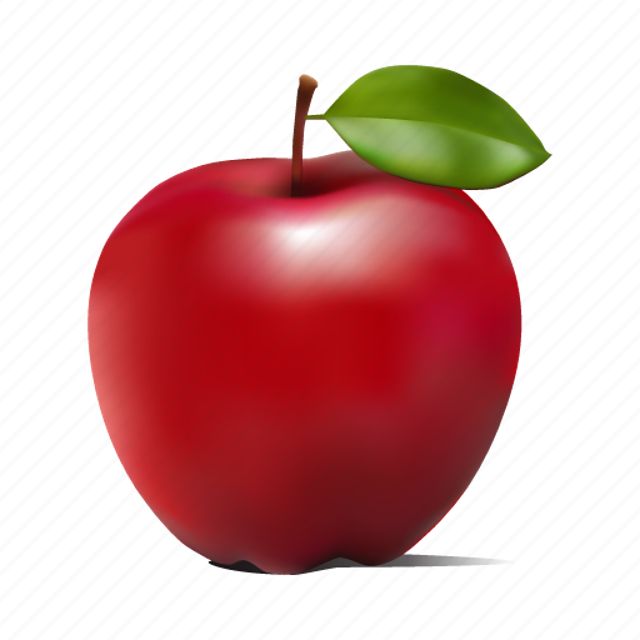

In [38]:
image = Image.open(list(Image_dict.keys())[0])
image = image.resize((640, 640))  # 画像を640x640にリサイズ



In [ ]:
import albumentations as A
import cv2

# 画像の回転や反転を適用
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=30)
])

image = cv2.imread("sample.jpg")
augmented = transform(image=image)["image"]
cv2.imwrite("augmented.jpg", augmented)